In [1]:
import torch
import os 
from pathlib import Path
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
os.chdir('../..')

In [3]:
PATH_TO_GRADS = Path('experiments/CV/logs')

In [19]:
# def read_params_grads(exp, version=None, param_name='fc.weight'): 
#     if not version:
#         version = sorted(os.listdir( PATH_TO_GRADS / exp), key=lambda x: float(x.split('_')[-1]))[-1]
#     path = PATH_TO_GRADS / exp / f'{version}' / param_name 
#     params, grads = [], []
#     for file in os.listdir(path):
#         file_path = path / file 
#         if 'grad' in file:
#             grads.append(torch.load(file_path))
#         else: 
#             params.append(torch.load(file_path))
#     return torch.stack(params), torch.stack(grads)
        
import yaml
from pathlib import Path
from softstairs_qat.utils.t_scheduler import TScheduler 


def read_params_grads(exp, version=None, param_name='fc.weight'):
    if not version:
        version = sorted(os.listdir(PATH_TO_GRADS / exp), key=lambda x: float(x.split('_')[-1]))[-1]
    
    # Parse hparams.yaml from the experiment directory
    hparams_path: Path = PATH_TO_GRADS / exp /  f'version_{version}' /  'hparams.yaml'
    with open(hparams_path, 'r') as f:
        hparams = yaml.safe_load(f)
    
    # Create TScheduler from hparams
    # Adjust these keys based on your actual hparams.yaml structure
    
    hparams = hparams.get('quantization_hparams')
    n_steps = hparams.get('n_steps', 30)
    scheduler = TScheduler(
        strategy=hparams.get('t_scheduler_strategy', 'linear'),
        start_t=hparams.get('t_start', 0.9),
        end_t=hparams.get('t_end', 5e-2),
        total_steps=n_steps,
        early_power=hparams.get('early_power', 0.95),
        min_majorant=hparams.get('min_majorant', 0.)
    )
    
    path = hparams_path.parent / param_name
    params, grads = [], []
    order_g, order_p = [], []
    # print(path)
    for file in os.listdir(path):
        order = tuple(map(int, file[:-len('.pth')].split('_')[1].split('.')))
        file_path = path / file 
        if 'grad' in file:
            grads.append(torch.load(file_path))
            order_g.append(order)
        else: 
            params.append(torch.load(file_path))
            order_p.append(order)

    def argsort(seq):
        return [x for x, y in sorted(enumerate(seq), key = lambda x: x[1])]
    
    if len(order) == 1:
        P = 1
    else:
        P = len(set(i[1] for i in order_g))
    order_g = argsort((order_g))
    order_p = argsort((order_p))
    
    return torch.stack(params)[order_p], torch.stack(grads)[order_g], scheduler, P

In [22]:
EXPERIMENT = 'InceptionNet_STL10_strcyclic_af1_b8_tstandard_majNone_norm'
VERSION = 5 
PARAM_SCOPE = 'Mixed_6e.branch1x1.conv.weight'
# PARAM_SCOPE = 'fc.weight'

In [62]:
# ps, gs = read_params_grads('InceptionNet_STL10_strcyclic_af1_b8_tstandard_majNone_norm')
ps, gs, scheduler, P = read_params_grads(EXPERIMENT, VERSION, PARAM_SCOPE)

'Mixed_6e.branch1x1.conv.weight'

'Mixed_6e.branch1x1.conv.weight'

In [63]:
ps.size()

torch.Size([260, 192, 768, 1, 1])

In [25]:
from softstairs_qat.core.soft_stairs import softstairs_naive, SoftStairs
from softstairs_qat.utils.t_scheduler import TScheduler


# scheduler = TScheduler('cyclic', 0.9, 5e-4, total_steps=30, early_power=.95, min_majorant=0.)
# scheduler = TScheduler('linear', 0.9, 5e-2, total_steps=31, early_power=.95, min_majorant=0.)

T_SCHEDULE = scheduler.strategy

In [26]:
def quant_error(ps, t):
    if isinstance(t, float):
        return softstairs_naive(ps, t) - (ps).round()
    errors = ps.clone() 
    for i, p in enumerate(errors):
        errors[i] = SoftStairs(t[i]).forward(p) 
    return errors


def sensibility_weight(ps):
    return ps - ps.round()

def sensibility_ss(ps, t, normalized=False, af=1): 
    if isinstance(t, float):
        return SoftStairs(t, normalized=normalized, async_t_factor=af).derivative(ps)
    sensibilities = ps.clone() 
    for i, p in enumerate(sensibilities):
        sensibilities[i] = SoftStairs(t[i], normalized=normalized, async_t_factor=af).derivative(p) 
    return sensibilities

def grad_on_final_weight(ps, gs, t, normalized=True, af=1):
    D = sensibility_ss(ps, t, normalized, af)
    G = gs * D # double-check this moment: where the gradient is cached down?
    return G 



IndexError: list index out of range

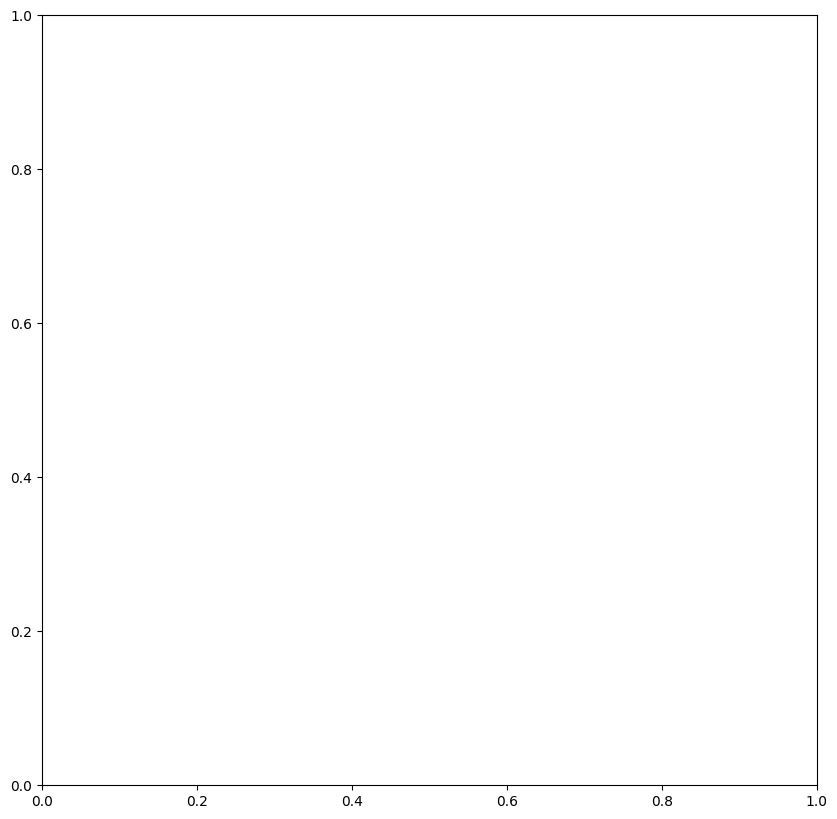

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
import seaborn as sns 

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, kde



def get_kde(data, n_dots, max_percentile=10):
    x_grid = np.linspace(data.min(), np.percentile(data, max_percentile), n_dots)
    # Compute KDE for each epoch
    kdes = []
    for datum in data:
        try:
            kde = gaussian_kde(datum)
            kdes.append(kde(x_grid))
        except np.linalg.LinAlgError:
            # If it fails, fill this row with NaNs or a very low value
            print("Warning: Singular matrix encountered. Filling row with zeros.")
            kdes.append(np.zeros_like(x_grid))
    kdes = np.array(kdes)
    return kdes, x_grid

SIZE = 10, 10,
fig, ax = plt.subplots(1, 1, figsize=SIZE)
max_percentile = 90
kdes, x_grid = get_kde(sensibility_ss(ps.flatten(start_dim=1), scheduler.get_all_t()), 100, max_percentile=max_percentile)
sns.heatmap(np.log(kdes), xticklabels=x_grid, ax=ax)
plt.xticks(ticks=torch.arange(0, len(x_grid), 2), labels=[f'{float(i):.4f}' for idx, i in enumerate(x_grid) if not idx % 2])
plt.ylabel('epoch')
plt.title(f'KDE dynamics: max_percentile = {max_percentile}, ')



In [28]:
def weight_transitions(ps):
    s = ps.numel() / ps.shape[0]
    return (ps.round().diff(axis=0).flatten(start_dim=1) > 0.).int().sum(1) / s

In [ ]:
ps.argsort()

In [65]:
ps.size()

torch.Size([260, 192, 768, 1, 1])

In [66]:
changed.size()

torch.Size([259, 147456])

In [ ]:

import torch
def _intersection_size_sorted(a_sorted, b_sorted, pad=-1):
    """
    a_sorted, b_sorted: (N, k) sorted int64 tensors.
    Returns |A_i ∩ B_i| per row, ignoring `pad` entries.
    """
    N, k = a_sorted.shape
    left_raw = torch.searchsorted(b_sorted, a_sorted)     # in [0, k]
    in_range = left_raw < k
    left = left_raw.clamp_max(k - 1)
    hit = in_range & (b_sorted.gather(1, left) == a_sorted)
    hit &= (a_sorted != pad)                              # <-- critical
    return hit.sum(dim=1).float()


def jaccard_over_epochs(ps, k: float, round: bool = False, chunk: int = 64):
    if round:
        # Only need codes to identify transitions.
        codes = ps.float().flatten(1).round()
        changed = codes[1:] != codes[:-1]          # (E-1, P)

        # Reuse a single tensor for transition magnitudes.
        deltas = (ps[1:] - ps[:-1]).flatten(1).abs()
        deltas.masked_fill_(~changed, -float("inf"))

        k_abs = max(1, int(codes.size(-1) * k))

        # No argsort: O(P) selection rather than O(P log P).
        topk_transitions = deltas.topk(k_abs, dim=1).indices

        # A transition with no valid change has index corresponding to -inf.
        valid = torch.isfinite(
            deltas.gather(1, topk_transitions)
        )

        # Jaccard without Python sets.
        #
        # Sort the selected indices, then use searchsorted to count
        # intersections row-wise.
        topk_transitions = topk_transitions.masked_fill(~valid, -1)
        sorted_idx = topk_transitions.sort(dim=1).values

        a = sorted_idx[:-1]
        b = sorted_idx[1:]

        # Number of valid elements.
        na = (a >= 0).sum(dim=1)
        nb = (b >= 0).sum(dim=1)

        # Count A elements occurring in B.
        pos = torch.searchsorted(b, a)
        pos_clamped = pos.clamp_max(k_abs - 1)

        hit = (
            (pos < k_abs)
            & (a >= 0)
            & (b.gather(1, pos_clamped) == a)
        )

        inter = hit.sum(dim=1)

        union = na + nb - inter

        jaccards = inter.float() / union.clamp_min(1).float()
        # deltas = (ps[1:] - ps[:-1]).flatten().abs()
        # codes = ps.float().flatten(1).round()

        # changed = codes[1:] != codes[:-1]
        # # shape: (E-1, P)

        # inter = changed[:-1] & changed[1:]
        # union = changed[:-1] | changed[1:]

        # jaccards = (
        #     inter.sum(dim=1).float()
        #     / union.sum(dim=1).clamp_min(1).float()
        # )
        return jaccards
    
    E = ps.shape[0]
    if E < 3:
        return ps.new_empty(0, dtype=torch.float)

    s = ps[0].numel()
    k_abs = int(k * s) if k <= 1.0 else int(k)
    k_abs = min(k_abs, s)

    PAD = -1
    topk_idx = torch.full((E - 1, k_abs), PAD, dtype=torch.long, device=ps.device)

    for t0 in range(0, E - 1, chunk):
        t1 = min(t0 + chunk, E - 1)
        p0 = ps[t0:t1].float().flatten(1)
        p1 = ps[t0 + 1:t1 + 1].float().flatten(1)

        if round:
            r0, r1 = p0.round(), p1.round()
            switch = (r1 != r0)
            d = (r1 - r0).abs().masked_fill(~switch, float('-inf'))
            n_valid = switch.sum(dim=1)                  # (c,)
        else:
            d = (p1 - p0).abs()
            n_valid = None

        kk = d.topk(k_abs, dim=1).indices
        if round:
            ar = torch.arange(k_abs, device=ps.device).unsqueeze(0)
            valid = ar < n_valid.unsqueeze(1)
            kk = kk.masked_fill(~valid, PAD)
        topk_idx[t0:t1] = kk

    a = topk_idx[:-1]
    b = topk_idx[1:]

    a_sorted, _ = a.sort(dim=1)
    b_sorted, _ = b.sort(dim=1)

    inter = _intersection_size_sorted(a_sorted, b_sorted, pad=PAD)

    if round:
        a_valid = (a != PAD).sum(dim=1).float()
        b_valid = (b != PAD).sum(dim=1).float()
    else:
        a_valid = a.new_full((a.shape[0],), float(a.shape[1]))
        b_valid = a.new_full((b.shape[0],), float(b.shape[1]))

    union = a_valid + b_valid - inter
    return inter / union


jvals = jaccard_over_epochs(ps, 1, round=True)

In [94]:
PARAM_SCOPE

'Mixed_6e.branch1x1.conv.weight'

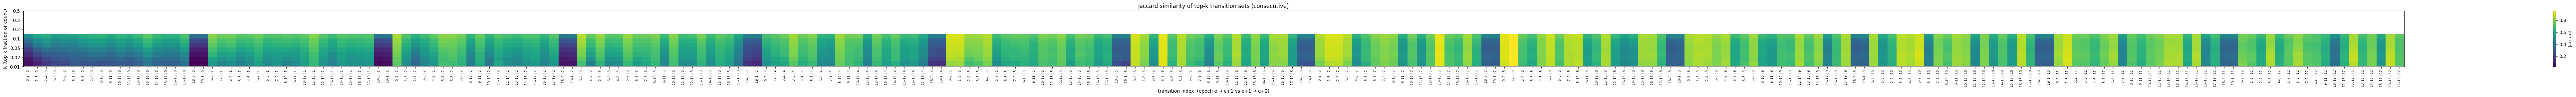

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


def jaccard_transition(ps, k_grid, round=False):
    jvals = []
    for k in k_grid:
        jvals.append(jaccard_over_epochs(ps, k, round=round))
    # stack into (len(k_grid), num_consecutive_pairs)
    J = torch.stack([j.float() for j in jvals], dim=0).numpy()
    return J


def plot_jaccard(J, k_grid, epochs=None):
    """
    J: (num_k, num_pairs) matrix from jaccard_transition
    k_grid: list/array of k values (len == J.shape[0])
    epochs: optional x-tick labels (length J.shape[1] + 2 = E)
    """
    num_k, num_pairs = J.shape
    x = np.arange(num_pairs)
    y = np.asarray(k_grid, dtype=float)

    # ---------- Heatmap ----------
    fig, ax = plt.subplots(figsize=(max(6, num_pairs * 0.35), max(3, num_k * 0.35)))
    im = ax.imshow(
        J, aspect='auto', origin='lower', cmap='viridis',
        extent=[x[0] - 0.5, x[-1] + 0.5, y[0], y[-1]],
    )
    ax.set_xlabel('transition index  (epoch e → e+1 vs e+1 → e+2)')
    ax.set_yticks(np.arange(len(k_grid)) / len(k_grid), k_grid)
    ax.set_ylabel('k (top-k fraction or count)')
    ax.set_title('Jaccard similarity of top-k transition sets (consecutive)')
    fig.colorbar(im, ax=ax, label='Jaccard')
    if epochs is not None and len(epochs) == num_pairs + 2:
        ax.set_xticks(x)
        
        ax.set_xticklabels([f'{epochs[i] % P}–{epochs[i+2] % P} | {epochs[i] // P}' for i in x],
                           rotation=90, fontsize=7)
    plt.tight_layout()
    plt.show()


# Usage
k_grid = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5,]
J = jaccard_transition(ps, k_grid, round=False)     # shape (len(k_grid), E-2)
plot_jaccard(J, k_grid, epochs=list(range(ps.shape[0])))

In [93]:
import numpy as np
import plotly.graph_objects as go


def plot_jaccard_3d_interactive(J, k_grid, epochs=None,
                                title='Top-k transition Jaccard',
                                zmin=0.0, zmax=1.0, path=''):
    """
    J: (num_k, num_pairs) numpy array
    k_grid: sequence of k values (len == J.shape[0])
    epochs: optional full epoch list (len == J.shape[1] + 2) for nicer x labels
    """
    num_k, num_pairs = J.shape
    x = np.arange(num_pairs)
    y = np.asarray(k_grid, dtype=float)

    # x labels: label each column by the epoch pair it compares
    if epochs is not None and len(epochs) == num_pairs + 2:
        x_labels = [f'{epochs[i]}–{epochs[i+1]} vs {epochs[i+1]}–{epochs[i+2]}'
                    for i in x]
    else:
        x_labels = [str(i) for i in x]

    fig = go.Figure(data=[
        go.Surface(
            x=x, y=y, z=J,
            colorscale='Viridis',
            cmin=zmin, cmax=zmax,
            colorbar=dict(title='Jaccard'),
            hovertemplate=(
                'pair: %{customdata}<br>'
                'k: %{y:.4g}<br>'
                'Jaccard: %{z:.4f}<extra></extra>'
            ),
            customdata=np.broadcast_to(
                np.array(x_labels)[None, :], J.shape
            ),
        )
    ])

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis=dict(title='transition index', tickvals=x[::max(1, num_pairs // 20)],
                       ticktext=[x_labels[i] for i in x[::max(1, num_pairs // 20)]]),
            yaxis=dict(title='k', type='log' if (y > 0).all() and y.max() / y.min() > 50 else 'linear'),
            zaxis=dict(title='Jaccard', range=[zmin, zmax]),
            aspectmode='cube',
            camera=dict(eye=dict(x=1.6, y=1.6, z=1.0)),
        ),
        width=900, height=650,
        margin=dict(l=0, r=0, t=40, b=0),
    )
    if path:
        fig.write_html(path)
    fig.show()
    return fig


# Usage
J = jaccard_transition(ps, k_grid, round=True)   # (len(k_grid), E-2)
plot_jaccard_3d_interactive(J, k_grid, epochs=list(range(ps.shape[0])),
                            #  path=f'experiments/CV/logs/{EXPERIMENT}/version_{VERSION}/{PARAM_SCOPE}.html'
                             );

In [ ]:
def prop_trainable(ss, thr): 
    n = ss.numel() / ss.shape[0]
    return (ss > thr).to(int).sum(dim=tuple(range(1, ss.ndim))) / n


plt.figure(figsize=(10, 10))
sss = sensibility_ss(ps, scheduler.get_all_t())
thrs = np.linspace(sss.min(), np.percentile(sss, max_percentile), 10)
for thr in thrs:
    plt.plot(prop_trainable(sss, thr) * 100, label=f'dSS > {thr:.3f}')

plt.plot(np.array(scheduler.get_all_t()) * 100, label='t * 100', linestyle='--')

plt.legend(); 
plt.ylabel(' num: dSS > thr, %')
plt.xlabel('epoch')
plt.yticks(np.arange(0, 101, 2))
plt.xticks(np.arange(len(sss)))
plt.grid();

IndexError: list index out of range

<Figure size 1000x1000 with 0 Axes>

In [ ]:
fder = np.diff(sss, 1, 0, prepend=sss[:1, ]).reshape(sss.shape[0], -1) 

# plt.figure(figsize=(10, 10))
fig, axes = plt.subplots(2, 1, figsize =(10, 20))
# for ax in axes

axes[0].plot(np.linalg.norm(fder, ord=1, axis=(1,),)/ fder.shape[-1], label='mean L1 norm')
axes[0].plot(np.linalg.norm(fder, ord=2, axis=(1,),)/ fder.shape[-1], label='mean L2 norm')
plt.plot(np.mean(fder, axis=(1, ),) / fder.shape[-1] , label=f'mean / {fder.shape[-1]}')
plt.plot(np.percentile(fder, 90, axis=(1, ), ) / fder.shape[-1] , label=f'90 %ile / {fder.shape[-1]}')
plt.plot(np.percentile(fder, 10, axis=(1, ), ) / fder.shape[-1] , label=f'10 %ile / {fder.shape[-1]}')

for ax in axes:
    ax.set_xticks(np.arange(0, 30, 2))
    ax.legend()
    ax.set_xlabel('epoch')
    ax.grid() 
plt.suptitle(f'dSensibility per parameter tschedule = {T_SCHEDULE}');

NameError: name 'sss' is not defined

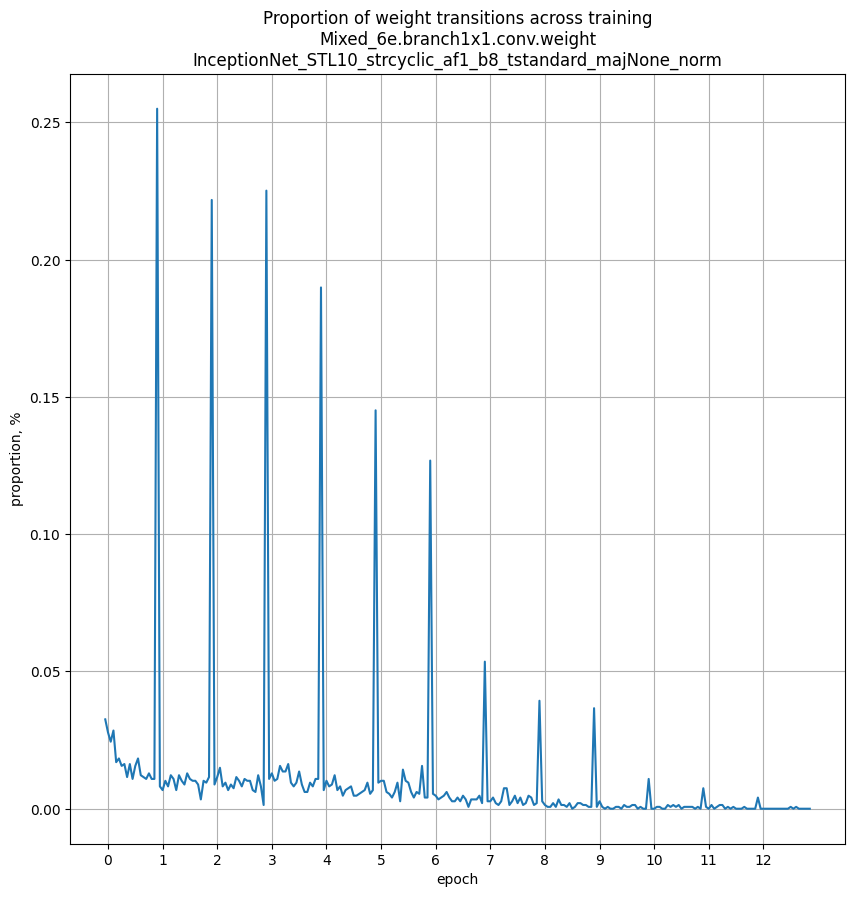

In [34]:
plt.figure(1, (10, 10))
plt.plot(weight_transitions(ps) * 100)
plt.grid();
plt.xlabel('epoch')
plt.xticks(np.arange(1, len(ps), P), [f'{i // P}' for i in range(1, len(ps), P)]); 
plt.title(f'Proportion of weight transitions across training\n{PARAM_SCOPE}\n{EXPERIMENT}'); 
plt.ylabel('proportion, %'); 


In [ ]:
def ema_over_time(x, decay=0.9):
    """
    x: [T, ...]
    returns: [...], EMA over dim=0
    """
    ema = x.clone()
    for t in range(1, x.shape[0]):
        ema = decay * ema + (1 - decay) * x[t]
    return ema

In [ ]:
jvals